In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
#Load dataset
df=pd.read_csv("Airbnb_Open_Data.csv")
df.head()

/tmp/ipykernel_13684/48778637.py:2: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [28]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='str')

In [29]:
# create same structured columns
df.columns=df.columns.str.lower().str.replace(" ","_")

In [30]:
df.columns

Index(['id', 'name', 'host_id', 'host_identity_verified', 'host_name',
       'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country',
       'country_code', 'instant_bookable', 'cancellation_policy', 'room_type',
       'construction_year', 'price', 'service_fee', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'review_rate_number', 'calculated_host_listings_count',
       'availability_365', 'house_rules', 'license'],
      dtype='str')

In [31]:
# check for missing values
df.isnull().sum()

id                                     0
name                                 250
host_id                                0
host_identity_verified               289
host_name                            406
neighbourhood_group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country_code                         131
instant_bookable                     105
cancellation_policy                   76
room_type                              0
construction_year                    214
price                                247
service_fee                          273
minimum_nights                       409
number_of_reviews                    183
last_review                        15893
reviews_per_month                  15879
review_rate_number                   326
calculated_host_listings_count       319
availability_365                     448
house_rules     

In [32]:
#percentage of missing values
df.isnull().sum()/len(df)*100

id                                 0.000000
name                               0.243667
host_id                            0.000000
host_identity_verified             0.281679
host_name                          0.395715
neighbourhood_group                0.028265
neighbourhood                      0.015595
lat                                0.007797
long                               0.007797
country                            0.518524
country_code                       0.127682
instant_bookable                   0.102340
cancellation_policy                0.074075
room_type                          0.000000
construction_year                  0.208579
price                              0.240743
service_fee                        0.266084
minimum_nights                     0.398639
number_of_reviews                  0.178364
last_review                       15.490404
reviews_per_month                 15.476759
review_rate_number                 0.317742
calculated_host_listings_count  

Handling Missing Values

In [33]:
# Convert 'last_review' to datetime and handle errors
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [34]:
# Fill missing values
df.fillna({'review_per_month': 0,'last_review':df['last_review'].min()},inplace=True)

# Drop records with missing 'name' or 'host name'
df.dropna(subset=['name', 'host_name'], inplace=True)

Data type correction

In [35]:
df.dtypes

id                                         int64
name                                         str
host_id                                    int64
host_identity_verified                       str
host_name                                    str
neighbourhood_group                          str
neighbourhood                                str
lat                                      float64
long                                     float64
country                                      str
country_code                                 str
instant_bookable                          object
cancellation_policy                          str
room_type                                    str
construction_year                        float64
price                                        str
service_fee                                  str
minimum_nights                           float64
number_of_reviews                        float64
last_review                       datetime64[us]
reviews_per_month   

In [ ]:

df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)
df['service_fee'] = df['service_fee'].str.replace('$', '', regex=False).str.replace(',', '').astype(float)




Remove duplicates

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
df.info()

<class 'pandas.DataFrame'>
Index: 101410 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              101410 non-null  int64         
 1   name                            101410 non-null  str           
 2   host_id                         101410 non-null  int64         
 3   host_identity_verified          101134 non-null  str           
 4   host_name                       101410 non-null  str           
 5   neighbourhood_group             101384 non-null  str           
 6   neighbourhood                   101394 non-null  str           
 7   lat                             101402 non-null  float64       
 8   long                            101402 non-null  float64       
 9   country                         100884 non-null  str           
 10  country_code                    101288 non-null  str           
 11  ins

Descriptive Statistics

In [41]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
id,101410.0,29209587.716803,1001254.0,15075735.0,29229113.0,43283077.0,57367417.0,16268196.064995
host_id,101410.0,49261546471.413521,123600518.0,24591832845.25,49120689588.0,73997470050.25,98763129024.0,28537026758.869961
lat,101402.0,40.728082,40.49979,40.68873,40.7223,40.76275,40.91697,0.05585
long,101402.0,-73.949663,-74.24984,-73.98257,-73.95444,-73.93234,-73.70522,0.049474
construction_year,101210.0,2012.486908,2003.0,2007.0,2012.0,2017.0,2022.0,5.76513
price,101171.0,625.381008,50.0,340.0,625.0,913.0,1200.0,331.609111
service_fee,101142.0,125.043998,10.0,68.0,125.0,183.0,240.0,66.313374
minimum_nights,101016.0,8.113744,-1223.0,2.0,3.0,5.0,5645.0,30.378014
number_of_reviews,101228.0,27.511854,0.0,1.0,7.0,31.0,1024.0,49.549258
last_review,101410,2018-05-15 21:26:08.721033,2012-07-11 00:00:00,2017-07-30 00:00:00,2019-05-23 00:00:00,2019-07-01 00:00:00,2058-06-16 00:00:00,NaN


Visualization

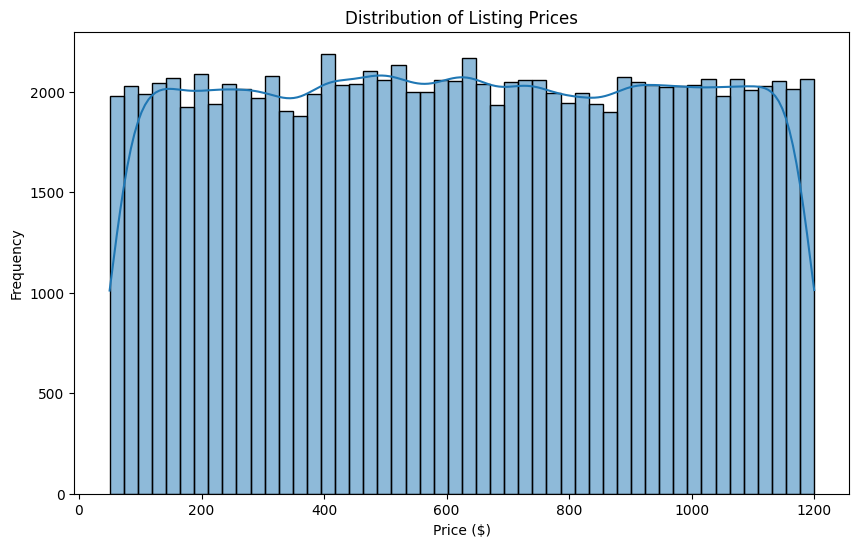

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_13684/3783948471.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='room_type', data=df, palette='viridis')


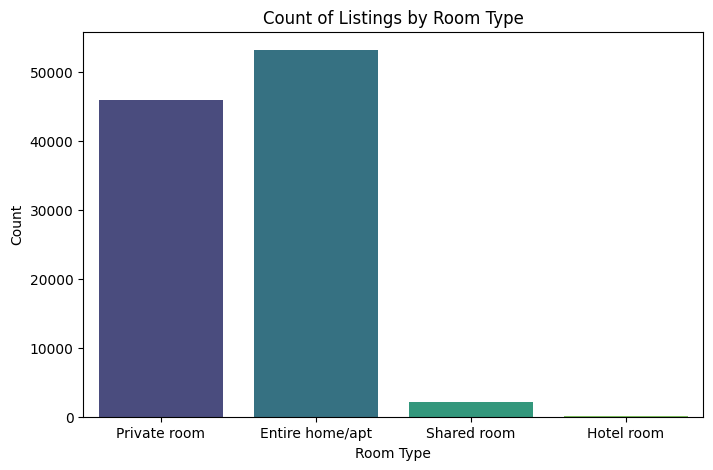

In [43]:
plt.figure(figsize=(8,5))
sns.countplot(x='room_type', data=df, palette='viridis')
plt.title('Count of Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

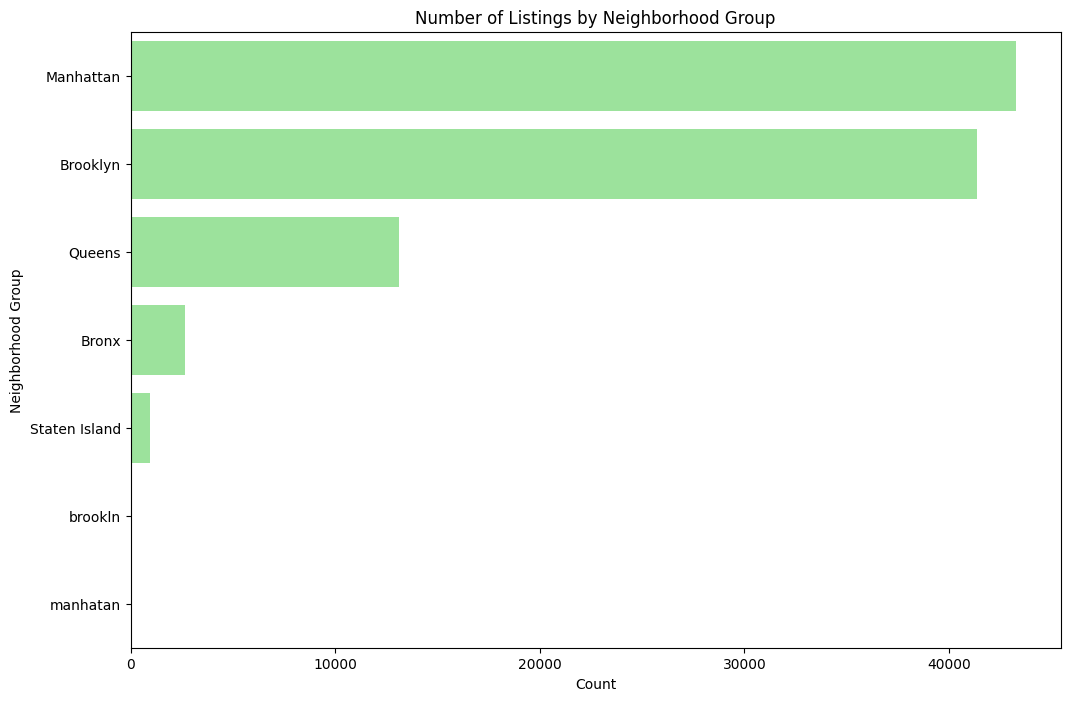

In [47]:
plt.figure(figsize=(12, 8))
sns.countplot(y='neighbourhood_group', data=df,color="lightgreen" , order=df['neighbourhood_group'].value_counts().index)
plt.title('Number of Listings by Neighborhood Group')
plt.xlabel('Count')
plt.ylabel('Neighborhood Group')
plt.show()

/tmp/ipykernel_13684/2734788128.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Room Type')


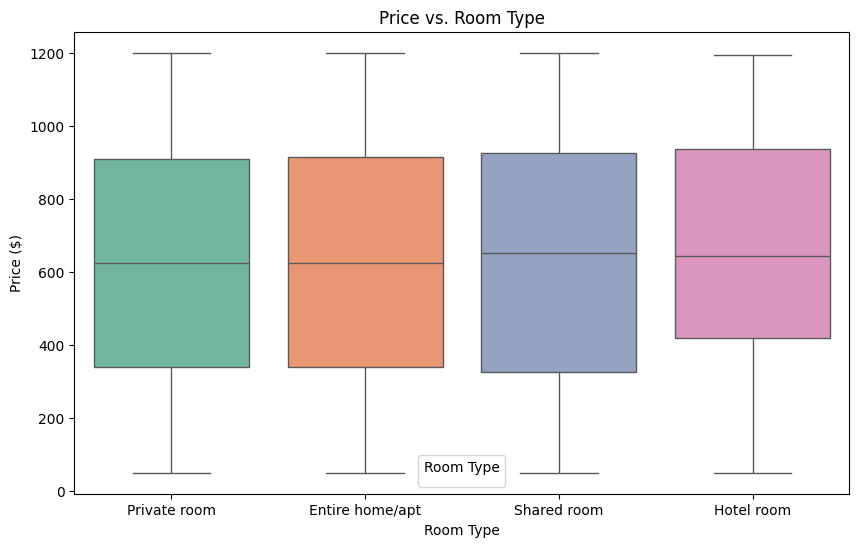

In [48]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', hue='room_type', data=df, palette='Set2')
plt.title('Price vs. Room Type')
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.legend(title='Room Type')
plt.show()

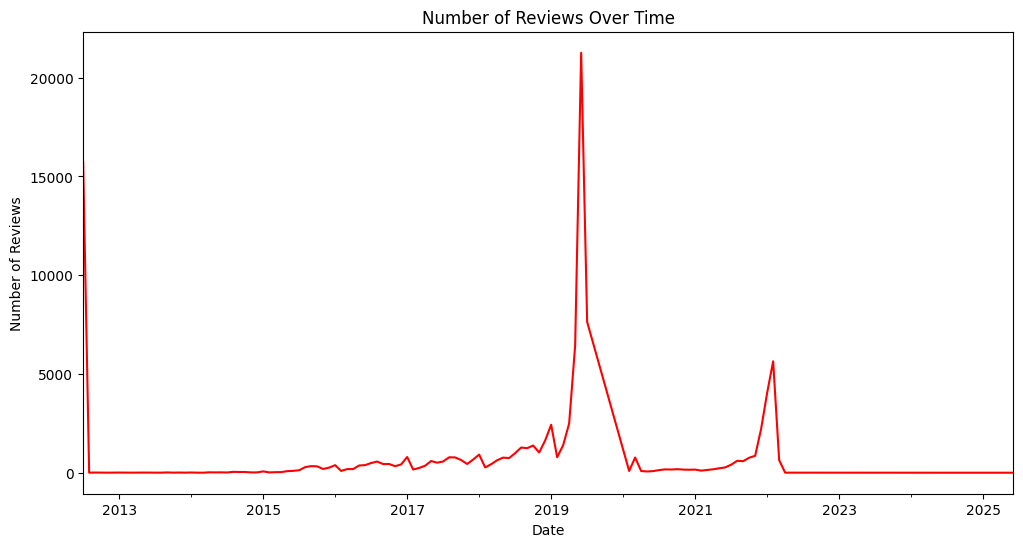

In [55]:
df['last_review'] = pd.to_datetime(df['last_review'])
df_filtered = df[df['last_review'].dt.year <= 2025]
reviews_over_time = df_filtered.groupby(df_filtered['last_review'].dt.to_period('M')).size()

plt.figure(figsize=(12, 6))
reviews_over_time.plot(kind='line',color='red')
plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()